In [1]:
# ==========================================
# CELL 1: IMPORT THƯ VIỆN & KHỞI TẠO TỪ ĐIỂN
# ==========================================

# 1. Các thư viện cốt lõi xử lý dữ liệu và cấu trúc hệ thống
import os
import urllib.request
import pandas as pd
import numpy as np

# 2. Các thư viện trực quan hóa dữ liệu (EDA) cho báo cáo
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Các thư viện tiền xử lý văn bản tiếng Việt và mô hình hóa
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 4. Cấu hình giao diện biểu đồ cho đồng bộ và trực quan
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'  # Đảm bảo hiển thị tốt tiếng Việt

# 5. Định nghĩa bộ từ điển Acronyms / Emoticons chuẩn của bộ dữ liệu UIT-VSFC
# (Giúp giữ lại sắc thái cảm xúc của sinh viên trước khi xóa dấu câu)
ACRONYMS_DICT = {
    ":)": "colonsmile",
    ":(": "colonsad",
    "@@": "colonsurprise",
    "<3": "colonlove",
    ":d": "colonsmilesmile",
    ":3": "coloncontemn",
    ":v": "colonbigsmile",
    ":_": "coloncc",
    ":p": "colonsmallsmile",
    ">>\n": "coloncolon",
    ":\">": "colonlovelove",
    "^^": "colonhihi",
    ": ": "doubledot ",
    "':(': ": "colonsadcolon ",
    "’(": "colonsadcolon",
    ":@": "colondoublesurprise",
    "v.v": "vdotv",
    "...": "dotdotdot",
    "/": "fraction",
    "c#": "cshrap"
}

print("✅ CELL 1 HOÀN THÀNH: Đã nạp đầy đủ thư viện và cấu hình bộ từ điển Acronyms!")

✅ CELL 1 HOÀN THÀNH: Đã nạp đầy đủ thư viện và cấu hình bộ từ điển Acronyms!


In [ ]:
# =====================================================================
# CELL 2: KIỂM TOÁN VÀ THỐNG KÊ SỐ DÒNG THỰC TẾ CỦA BỘ DỮ LIỆU MỚI
# =====================================================================
import os

# Cấu hình đường dẫn tới các folder trong bộ dữ liệu mới của bạn
dataset_dirs = {
    "TẬP HUẤN LUYỆN (TRAIN)": "../data/raw/train/",
    "TẬP PHÁT TRIỂN (DEV)": "../data/raw/dev/",
    "TẬP KIỂM THỬ (TEST)": "../data/raw/test/"
}

print("📊 ĐANG TIẾN HÀNH QUÉT VÀ ĐẾM SỐ DÒNG THỰC TẾ TRÊN Ổ CỨNG...")
print("=" * 70)

total_all_sentences = 0

# Duyệt qua từng thư mục để đếm số dòng của từng file .txt
for group_name, folder_path in dataset_dirs.items():
    print(f"\n📂 {group_name}:")
    if not os.path.exists(folder_path):
        print(f"  ❌ Cảnh báo: Không tìm thấy thư mục {folder_path}")
        continue
        
    for file_name in ["sents.txt", "sentiments.txt", "topics.txt"]:
        file_path = os.path.join(folder_path, file_name)
        if os.path.exists(file_path):
            with open(file_path, "r", encoding="utf-8") as f:
                # Đếm số dòng thực tế sau khi tách dòng
                line_count = len(f.read().splitlines())
            print(f"  📄 {file_name:<15} -> {line_count:>6} dòng")
            
            # Chỉ cộng dồn số câu từ file sents.txt để tính tổng dung lượng dataset
            if file_name == "sents.txt":
                total_all_sentences += line_count
        else:
            print(f"  ❌ Không tìm thấy file: {file_name}")

print("\n" + "=" * 70)
print(f"📈 TỔNG CỘNG SỐ CÂU QUÉT ĐƯỢC TRONG TOÀN BỘ DATASET: {total_all_sentences} câu")
print("=" * 70)

# Đối chiếu nhanh với tiêu chuẩn của ĐHQG
print("\n🔍 ĐỐI CHIẾU VỚI TIÊU CHUẨN DATASET GỐC (UIT-VSFC):")
if total_all_sentences >= 16000:
    print("🎉 TUYỆT VỜI! Bộ dữ liệu này ĐẦY ĐỦ 100% (Có cả Train, Dev, Test gốc).")
elif 11000 <= total_all_sentences <= 12000:
    print("⚠️ CHÚ Ý: Bộ dữ liệu này CHỈ CÓ MỖI TẬP TRAIN GỐC (Hơn 11k câu), thiếu file của tập Dev và Test.")
else:
    print("❌ CẢNH BÁO: Bộ dữ liệu này vẫn bị thiếu dòng, hãy kiểm tra lại nguồn file.")

📊 ĐANG TIẾN HÀNH QUÉT VÀ ĐẾM SỐ DÒNG THỰC TẾ TRÊN Ổ CỨNG...

📂 TẬP HUẤN LUYỆN (TRAIN):
  📄 sents.txt       ->  11426 dòng
  📄 sentiments.txt  ->  11426 dòng
  📄 topics.txt      ->  11426 dòng

📂 TẬP PHÁT TRIỂN (DEV):
  📄 sents.txt       ->   1583 dòng
  📄 sentiments.txt  ->   1583 dòng
  📄 topics.txt      ->   1583 dòng

📂 TẬP KIỂM THỬ (TEST):
  📄 sents.txt       ->   3166 dòng
  📄 sentiments.txt  ->   3166 dòng
  📄 topics.txt      ->   3166 dòng

📈 TỔNG CỘNG SỐ CÂU QUÉT ĐƯỢC TRONG TOÀN BỘ DATASET: 16175 câu

🔍 ĐỐI CHIẾU VỚI TIÊU CHUẨN DATASET GỐC (UIT-VSFC):
🎉 TUYỆT VỜI! Bộ dữ liệu này ĐẦY ĐỦ 100% (Có cả Train, Dev, Test gốc).


In [3]:
# =====================================================================
# CELL 3 (THEO THỨ TỰ CỦA BẠN): ĐỌC DỮ LIỆU THÔ AN TOÀN & GOM THÀNH DATAFRAME
# =====================================================================

# Khai báo đường dẫn chuẩn đến 3 file văn bản của tập Train trong thư mục raw
sents_train_path = "../data/raw/train/sents.txt"
sentiments_train_path = "../data/raw/train/sentiments.txt"
topics_train_path = "../data/raw/train/topics.txt"

print("⏳ Đang tiến hành đọc và đồng bộ hóa cấu trúc dữ liệu UIT-VSFC...")

try:
    # Đọc từng tệp tin một cách an toàn, tự động loại bỏ ký tự xuống dòng (\n) bằng splitlines
    with open(sents_train_path, 'r', encoding='utf-8') as f:
        train_sents = f.read().splitlines()
        
    with open(sentiments_train_path, 'r', encoding='utf-8') as f:
        train_sentiments = f.read().splitlines()
        
    with open(topics_train_path, 'r', encoding='utf-8') as f:
        train_topics = f.read().splitlines()
        
    # Ghép 3 danh sách song song này thành 1 bảng DataFrame duy nhất
    df_train = pd.DataFrame({
        'text': train_sents,
        'sentiment': train_sentiments,
        'topic': train_topics
    })
    
    print("✅ Quá trình đọc dữ liệu và khởi tạo DataFrame thành công!\n")
    
    # 1. Hiển thị trực quan 5 dòng đầu tiên để kiểm tra form dữ liệu
    print("👀 Xem thử 5 dòng dữ liệu đầu tiên của tập Train:")
    display(df_train.head())
    
    # 2. Xuất thông số cấu trúc để đối chiếu kiểm tra số dòng
    print("\n" + "="*45)
    print("📊 THỐNG KÊ CHI TIẾT BỘ DỮ LIỆU TẬP TRAIN")
    print("="*45)
    print(f"- Tổng số mẫu phản hồi (Số dòng): {df_train.shape[0]}")
    print(f"- Số lượng thuộc tính nhãn (Số cột): {df_train.shape[1]}")
    print(f"- Định dạng các cột dữ liệu: {df_train.columns.tolist()}")
    
    # 3. Kiểm tra tính toàn vẹn (Xem có dòng nào bị trống/khuyết thiếu nhãn không)
    print("\n🔍 Kiểm tra giá trị khuyết thiếu (Missing values):")
    print(df_train.isnull().sum())

except FileNotFoundError as e:
    print(f"❌ Thất bại: Hệ thống không tìm thấy file dữ liệu tại đường dẫn khai báo. Chi tiết: {e}")

⏳ Đang tiến hành đọc và đồng bộ hóa cấu trúc dữ liệu UIT-VSFC...
✅ Quá trình đọc dữ liệu và khởi tạo DataFrame thành công!

👀 Xem thử 5 dòng dữ liệu đầu tiên của tập Train:


,text,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0



📊 THỐNG KÊ CHI TIẾT BỘ DỮ LIỆU TẬP TRAIN
- Tổng số mẫu phản hồi (Số dòng): 11426
- Số lượng thuộc tính nhãn (Số cột): 3
- Định dạng các cột dữ liệu: ['text', 'sentiment', 'topic']

🔍 Kiểm tra giá trị khuyết thiếu (Missing values):
text         0
sentiment    0
topic        0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11148\3003151549.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11148\3003151549.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='magma')


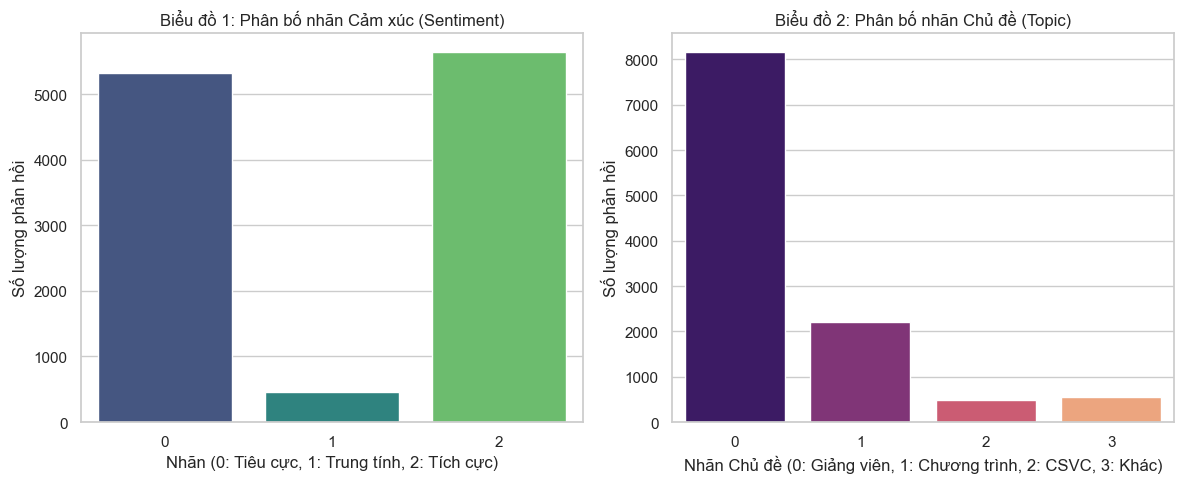


⏳ Đang tiến hành làm sạch dữ liệu...
- Đã dọn dẹp 0 dòng trùng lặp văn bản.
✅ Đã làm sạch xong! Xem thử kết quả trước và sau khi dọn:


,text,clean_text
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",nhiệt tình giảng dạy gần gũi với sinh viên
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",thầy giảng bài hay có nhiều bài tập ví dụ ngay...
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",giảng viên đảm bảo thời gian lên lớp tích cực ...
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",em sẽ nợ môn này nhưng em sẽ học lại ở các học...
7,"thời lượng học quá dài , không đảm bảo tiếp th...",thời lượng học quá dài không đảm bảo tiếp thu ...
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",nội dung môn học có phần thiếu trọng tâm hầu n...
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,cần nói rõ hơn bằng cách trình bày lên bảng th...


📁 Đã xuất bản và lưu file sạch vào: ../data/processed/train_cleaned.csv


In [9]:
# =====================================================================
# CELL 4: EDA (PHÂN TÍCH TRỰC QUAN) & LÀM SẠCH DỮ LIỆU NÂNG CAO
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Đổi tên DataFrame df_train (từ Cell 3) thành df để tiện xử lý
df = df_train.copy()

# ---------------------------------------------------------
# 1. VẼ 2 BIỂU ĐỒ PHÂN TÍCH (Bắt buộc cho báo cáo)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Phân bố Cảm xúc
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Biểu đồ 1: Phân bố nhãn Cảm xúc (Sentiment)')
plt.xlabel('Nhãn (0: Tiêu cực, 1: Trung tính, 2: Tích cực)')
plt.ylabel('Số lượng phản hồi')

# Biểu đồ 2: Phân bố Chủ đề
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='topic', palette='magma')
plt.title('Biểu đồ 2: Phân bố nhãn Chủ đề (Topic)')
plt.xlabel('Nhãn Chủ đề (0: Giảng viên, 1: Chương trình, 2: CSVC, 3: Khác)')
plt.ylabel('Số lượng phản hồi')

plt.tight_layout()
plt.show() # Chụp cái hình này dán vào báo cáo nhé!

# ---------------------------------------------------------
# 2. LÀM SẠCH DỮ LIỆU NÂNG CAO (Advanced Text Cleaning)
# ---------------------------------------------------------
print("\n⏳ Đang tiến hành làm sạch dữ liệu...")

# Xóa các dòng trùng lặp (nếu có)
rows_before = df.shape[0]
df = df.drop_duplicates(subset=['text'])
print(f"- Đã dọn dẹp {rows_before - df.shape[0]} dòng trùng lặp văn bản.")

# Hàm làm sạch văn bản NÂNG CAO (Giữ lại Icon)
def advanced_clean_text(text):
    text = str(text).lower() # Viết thường
    
    # Dịch các biểu tượng cảm xúc sang chữ (Dùng ACRONYMS_DICT từ Cell 1)
    for emo, text_replace in ACRONYMS_DICT.items():
        text = text.replace(emo.lower(), text_replace)
        
    # Sau khi dịch icon xong mới Xóa dấu câu (.,!?)
    text = re.sub(r'[^\w\s]', ' ', text) 
    
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

# Áp dụng hàm làm sạch vào cột text
df['clean_text'] = df['text'].apply(advanced_clean_text)

print("✅ Đã làm sạch xong! Xem thử kết quả trước và sau khi dọn:")
display(df[['text', 'clean_text']].head(10))

# ---------------------------------------------------------
# 3. LƯU LẠI DỮ LIỆU ĐÃ XỬ LÝ
# ---------------------------------------------------------
os.makedirs("../data/processed", exist_ok=True)
processed_path = "../data/processed/train_cleaned.csv"
df.to_csv(processed_path, index=False, encoding='utf-8')
print(f"📁 Đã xuất bản và lưu file sạch vào: {processed_path}")

In [8]:
# =====================================================================
# CELL 5: SỐ HÓA TF-IDF VÀ HUẤN LUYỆN MÔ HÌNH BASELINE TRÊN TẬP TEST GỐC
# =====================================================================
import pandas as pd
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Đọc lại tập Train đã làm sạch và lưu ở Cell 4
print("📁 Đang nạp tập dữ liệu Train sạch từ bộ nhớ...")
df_train = pd.read_csv("../data/processed/train_cleaned.csv")
df_train = df_train.dropna(subset=['clean_text', 'sentiment'])

# 2. Định nghĩa hàm đọc và làm sạch trực tiếp cho tập Test
# (Tái sử dụng hàm advanced_clean_text đã được định nghĩa ở Cell 4)
def load_and_clean_test_set(sents_path, sentiments_path):
    with open(sents_path, 'r', encoding='utf-8') as f:
        sents = f.read().splitlines()
    with open(sentiments_path, 'r', encoding='utf-8') as f:
        sentiments = f.read().splitlines()
        
    df = pd.DataFrame({'text': sents, 'sentiment': sentiments})
    
    # Áp dụng hàm làm sạch bảo tồn icon
    df['clean_text'] = df['text'].apply(advanced_clean_text)
    
    # Lọc bỏ các dòng bị rỗng sau khi làm sạch
    df = df.dropna(subset=['clean_text', 'sentiment'])
    
    # Đảm bảo nhãn cảm xúc ở định dạng số nguyên (integer)
    df['sentiment'] = df['sentiment'].astype(int)
    return df

print("📁 Đang nạp và làm sạch tập TEST chính thức (Đề thi niêm phong)...")
df_test = load_and_clean_test_set(
    "../data/raw/test/sents.txt", 
    "../data/raw/test/sentiments.txt"
)

# Ép kiểu dữ liệu nhãn Train sang số nguyên cho đồng bộ với Test
y_train = df_train['sentiment'].astype(int)
y_test = df_test['sentiment']

print("\n📊 THỐNG KÊ KÍCH THƯỚC BỘ DỮ LIỆU ĐI THI THỰC TẾ:")
print(f"  - Học trên tập Train: {df_train.shape[0]} câu")
print(f"  - Thi trên tập Test : {df_test.shape[0]} câu (Chuẩn UIT-VSFC!)")

# 3. TRÍCH XUẤT ĐẶC TRƯNG TF-IDF (Nguyên tắc cô lập tuyệt đối)
print("\n⏳ Đang tiến hành số hóa văn bản bằng ma trận TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000)

# CHỈ HỌC TỪ VỰNG TỪ TẬP TRAIN (fit_transform)
X_train_tfidf = vectorizer.fit_transform(df_train['clean_text'])

# ĐEM TỪ VỰNG ĐÓ ÁP DỤNG ĐỂ CHUYỂN ĐỔI TẬP TEST (chỉ transform)
X_test_tfidf = vectorizer.transform(df_test['clean_text'])

print("✅ Hoàn thành số hóa ma trận!")

# ---------------------------------------------------------
# 🤖 MÔ HÌNH 1: LOGISTIC REGRESSION
# ---------------------------------------------------------
print("\n" + "="*65)
print("🤖 MÔ HÌNH 1: LOGISTIC REGRESSION (ĐÁNH GIÁ TRÊN TẬP TEST CHÍNH THỨC)")
print("="*65)

start_time = time.time()
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"⏱️ Thời gian huấn luyện: {lr_time:.2f} giây")
print(classification_report(y_test, y_pred_lr, target_names=['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']))

# ---------------------------------------------------------
# 🤖 MÔ HÌNH 2: SUPPORT VECTOR MACHINE (SVM)
# ---------------------------------------------------------
print("\n" + "="*65)
print("🤖 MÔ HÌNH 2: SUPPORT VECTOR MACHINE (SVM) (ĐÁNH GIÁ TRÊN TẬP TEST CHÍNH THỨC)")
print("="*65)

start_time = time.time()
svm_model = SVC(kernel='linear') 
svm_model.fit(X_train_tfidf, y_train)
svm_time = time.time() - start_time

y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"⏱️ Thời gian huấn luyện: {svm_time:.2f} giây")
print(classification_report(y_test, y_pred_svm, target_names=['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']))

📁 Đang nạp tập dữ liệu Train sạch từ bộ nhớ...
📁 Đang nạp và làm sạch tập TEST chính thức (Đề thi niêm phong)...

📊 THỐNG KÊ KÍCH THƯỚC BỘ DỮ LIỆU ĐI THI THỰC TẾ:
  - Học trên tập Train: 11425 câu
  - Thi trên tập Test : 3166 câu (Chuẩn UIT-VSFC!)

⏳ Đang tiến hành số hóa văn bản bằng ma trận TF-IDF...
✅ Hoàn thành số hóa ma trận!

🤖 MÔ HÌNH 1: LOGISTIC REGRESSION (ĐÁNH GIÁ TRÊN TẬP TEST CHÍNH THỨC)
⏱️ Thời gian huấn luyện: 0.14 giây
                precision    recall  f1-score   support

  Tiêu cực (0)       0.85      0.95      0.90      1409
Trung tính (1)       0.61      0.08      0.15       167
  Tích cực (2)       0.91      0.90      0.91      1590

      accuracy                           0.88      3166
     macro avg       0.79      0.65      0.65      3166
  weighted avg       0.87      0.88      0.86      3166


🤖 MÔ HÌNH 2: SUPPORT VECTOR MACHINE (SVM) (ĐÁNH GIÁ TRÊN TẬP TEST CHÍNH THỨC)
⏱️ Thời gian huấn luyện: 5.68 giây
                precision    recall  f1-score   suppo

In [17]:
# =====================================================================
# CELL 6: BASELINE CHO PHÂN LOẠI CHỦ ĐỀ (TOPIC CLASSIFICATION)
# =====================================================================
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. ĐỌC DỮ LIỆU NHÃN CHỦ ĐỀ TỪ FILE CLEANED
# Nạp file đã tiền xử lý để đảm bảo số dòng khớp với X_train_tfidf (11425 dòng)
df_train = pd.read_csv('../data/processed/train_cleaned.csv')

# LƯU Ý: Bạn mở file train_cleaned.csv xem tên cột chủ đề là gì (ví dụ: 'topic', 'chu_de', 'label_topic'...) 
# Sau đó sửa lại tên 'topic' ở dòng dưới cho khớp nhé!
y_train_topic = df_train['topic'] 

# Tập test thường không bị rớt dòng nào do không fit lại, ta có thể nạp từ file txt
with open('../data/raw/test/topics.txt', 'r', encoding='utf-8') as f:
    y_test_topic = f.read().splitlines()
y_test_topic = [int(label) for label in y_test_topic]

print(f"✅ Đã nạp xong {len(y_train_topic)} nhãn chủ đề cho tập Train.")
print(f"✅ Đã nạp xong {len(y_test_topic)} nhãn chủ đề cho tập Test.")

target_names_topic = ['Giảng viên (0)', 'Chương trình (1)', 'Cơ sở vật chất (2)', 'Khác (3)']

# 2. HUẤN LUYỆN & ĐÁNH GIÁ: LOGISTIC REGRESSION
print("\n" + "="*50)
print("KẾT QUẢ MÔ HÌNH: LOGISTIC REGRESSION (CHỦ ĐỀ)")
print("="*50)
lr_topic_model = LogisticRegression(max_iter=1000, random_state=42)
lr_topic_model.fit(X_train_tfidf, y_train_topic)
y_pred_topic_lr = lr_topic_model.predict(X_test_tfidf)

print(classification_report(y_test_topic, y_pred_topic_lr, target_names=target_names_topic))


# 3. HUẤN LUYỆN & ĐÁNH GIÁ: SUPPORT VECTOR MACHINE (SVM)
print("\n" + "="*50)
print("KẾT QUẢ MÔ HÌNH: SUPPORT VECTOR MACHINE (CHỦ ĐỀ)")
print("="*50)
svm_topic_model = SVC(kernel='linear', random_state=42) 
svm_topic_model.fit(X_train_tfidf, y_train_topic)
y_pred_topic_svm = svm_topic_model.predict(X_test_tfidf)

print(classification_report(y_test_topic, y_pred_topic_svm, target_names=target_names_topic))

✅ Đã nạp xong 11425 nhãn chủ đề cho tập Train.
✅ Đã nạp xong 3166 nhãn chủ đề cho tập Test.

KẾT QUẢ MÔ HÌNH: LOGISTIC REGRESSION (CHỦ ĐỀ)
                    precision    recall  f1-score   support

    Giảng viên (0)       0.89      0.94      0.92      2290
  Chương trình (1)       0.70      0.68      0.69       572
Cơ sở vật chất (2)       0.97      0.84      0.90       145
          Khác (3)       0.65      0.25      0.36       159

          accuracy                           0.86      3166
         macro avg       0.80      0.68      0.72      3166
      weighted avg       0.85      0.86      0.85      3166


KẾT QUẢ MÔ HÌNH: SUPPORT VECTOR MACHINE (CHỦ ĐỀ)
                    precision    recall  f1-score   support

    Giảng viên (0)       0.89      0.94      0.91      2290
  Chương trình (1)       0.69      0.69      0.69       572
Cơ sở vật chất (2)       0.95      0.89      0.92       145
          Khác (3)       0.68      0.27      0.39       159

          accuracy        

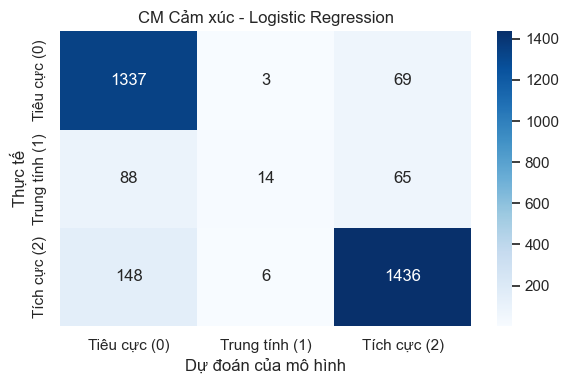

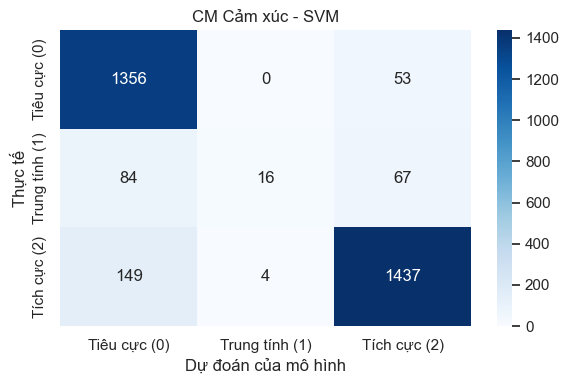

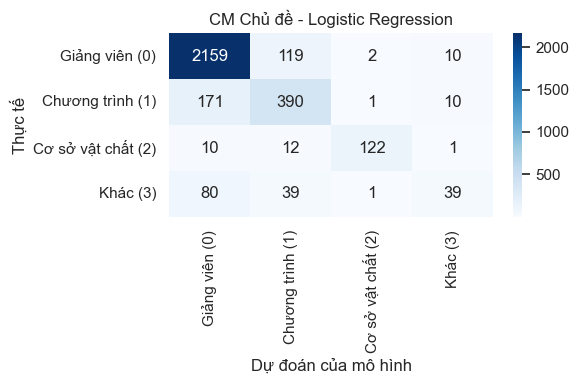

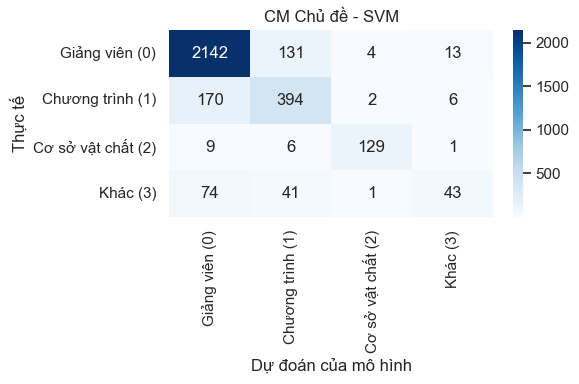

In [18]:
#-----------------------------------------
# CELL 7
#-----------------------------------------
# VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO BÁO CÁO
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Dự đoán của mô hình')
    plt.ylabel('Thực tế')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 1. CM Cảm xúc
plot_cm(y_test, y_pred_lr, ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)'], 'CM Cảm xúc - Logistic Regression')
plot_cm(y_test, y_pred_svm, ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)'], 'CM Cảm xúc - SVM')

# 2. CM Chủ đề
target_names_topic = ['Giảng viên (0)', 'Chương trình (1)', 'Cơ sở vật chất (2)', 'Khác (3)']
plot_cm(y_test_topic, y_pred_topic_lr, target_names_topic, 'CM Chủ đề - Logistic Regression')
plot_cm(y_test_topic, y_pred_topic_svm, target_names_topic, 'CM Chủ đề - SVM')

In [20]:
#-----------------------------------
# CELL 8
#----------------------------------

# LỌC CÁC CÂU DỰ ĐOÁN SAI ĐỂ ĐƯA VÀO BÁO CÁO (ERROR ANALYSIS)
df_errors = df_test.copy()
df_errors['Dự đoán_LR'] = y_pred_lr

# Lọc những câu lớp Thực tế = 1 (Trung tính) nhưng bị mô hình đoán sai
sai_trung_tinh = df_errors[(df_errors['sentiment'] == 1) & (df_errors['Dự đoán_LR'] != 1)]
pd.set_option('display.max_colwidth', None)
print("CÁC CÂU TRUNG TÍNH BỊ ĐOÁN SAI:")
display(sai_trung_tinh[['text', 'sentiment', 'Dự đoán_LR']].head(20))

CÁC CÂU TRUNG TÍNH BỊ ĐOÁN SAI:


,text,sentiment,Dự đoán_LR
27,cách mà cô tiếp cận với sinh viên .,1,2
35,môn học này giúp chúng em hiểu ra những vấn đề cơ bản .,1,2
53,như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết .,1,0
121,"ví dụ phù hợp với nội dung kiến thức , hướng dẫn chi tiết .",1,2
122,bài thuyết trình của các sinh viên .,1,2
162,giáo viên thực hành .,1,0
178,tâm lý .,1,2
235,thời gian học .,1,0
292,kỹ những chương cuối .,1,2
356,cả cuộc sống sau này lẫn trong môn học .,1,2
